<a href="https://colab.research.google.com/github/manvi-jain-git/first-contributions/blob/main/PYPROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter your weight in kg: 62

Enter food items you ate (type 'done' when finished):
Food name: Canned Apricots
Enter amount of Canned Apricots in grams: 100
Food name: Canned Blueberries
Enter amount of Canned Blueberries in grams: 50
Food name: Whoopie Pie
Enter amount of Whoopie Pie in grams: 150
Food name: Monkey Bread
Enter amount of Monkey Bread in grams: 200
Food name: Hot Dog Buns
Enter amount of Hot Dog Buns in grams: 120
Food name: done

Enter exercises you did (type 'done' when finished):
Exercise name: Cycling, >20 mph, racing
Enter duration of Cycling, >20 mph, racing in hours: 1
Exercise name: Swimming laps, freestyle, fast
Enter duration of Swimming laps, freestyle, fast in hours: 1
Exercise name: Walking, snow blower
Enter duration of Walking, snow blower in hours: 1
Exercise name: done

--- DAILY CALORIE SUMMARY ---
Total Calories Consumed: 1606.80 kcal
Total Calories Burned: 376.68 kcal
Net Calories: 1230.12 kcal

Predicted Net Calories (via Linear Regression): 1230.12 

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
<ipython-input-2-7a07c4eb3846>:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Calories Consumed', 'Calories Burned'], y=[consumed, burned], palette="Set2")


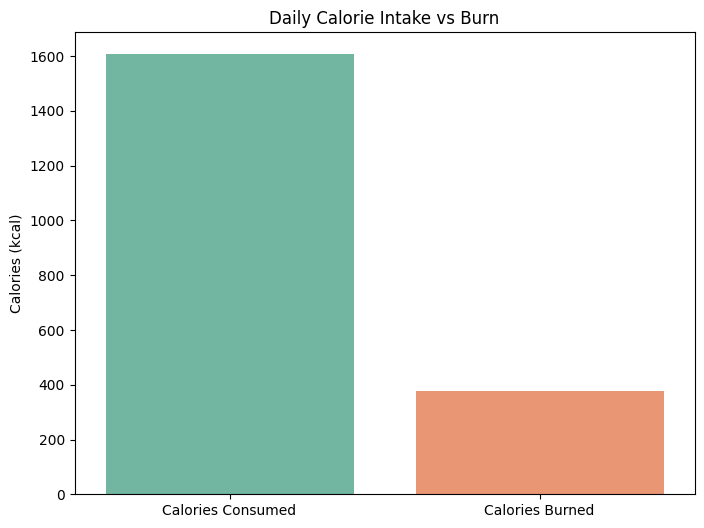

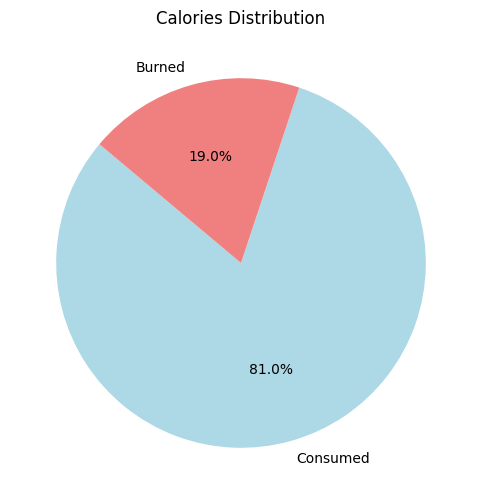

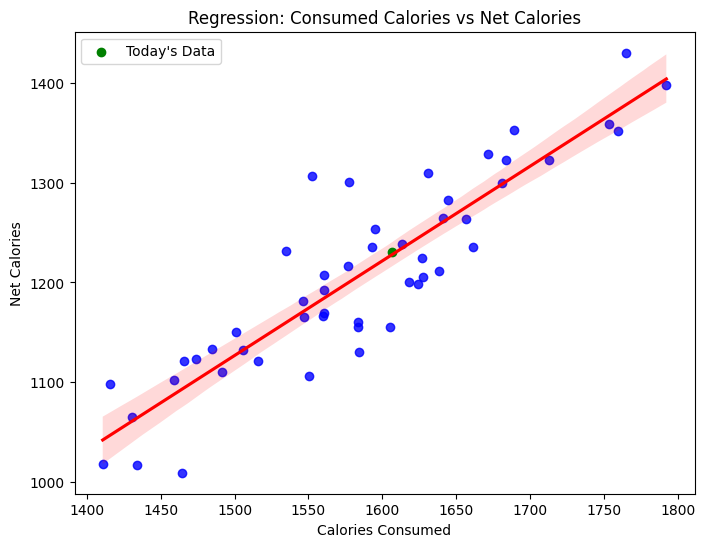

<ipython-input-2-7a07c4eb3846>:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(exercise_calories.keys()), y=list(exercise_calories.values()), palette="rocket")


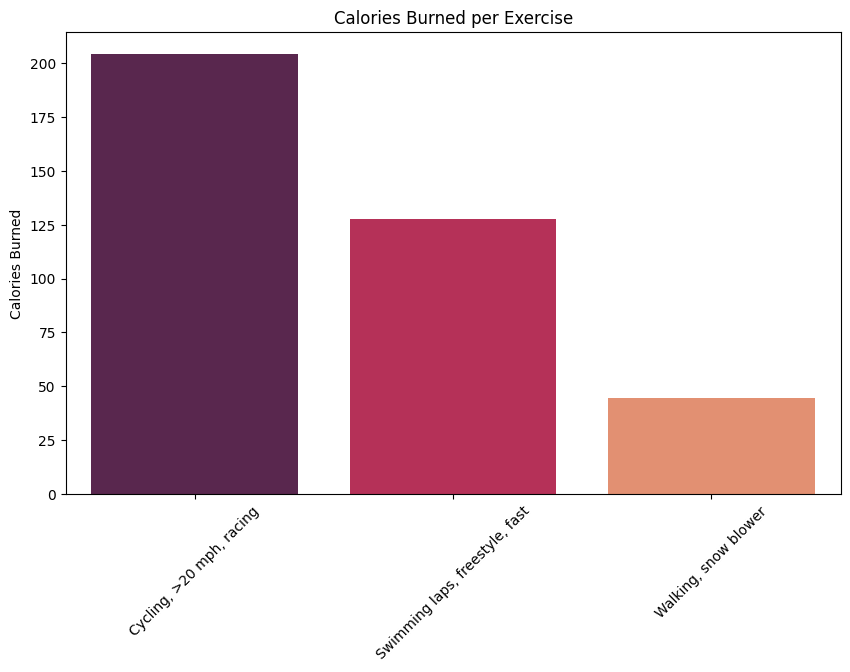

<ipython-input-2-7a07c4eb3846>:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(food_calories.keys()), y=list(food_calories.values()), palette="mako")


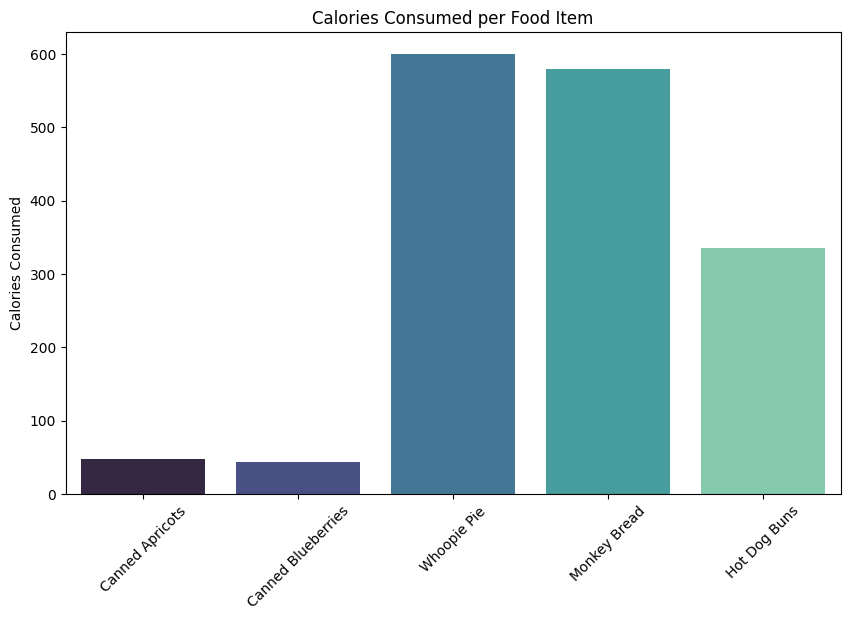


✅ Today's report saved successfully to 'calorie_report.csv'!

📋 --- SUMMARY DASHBOARD --- 📋
Total Days Tracked: 1
Average Calories Consumed: 1606.80 kcal
Average Calories Burned: 376.68 kcal
Average Net Calories: 1230.12 kcal

✅ Best Day (Lowest Net Calories): 2025-04-29 (1230.12 kcal)
⚠️ Worst Day (Highest Net Calories): 2025-04-29 (1230.12 kcal)


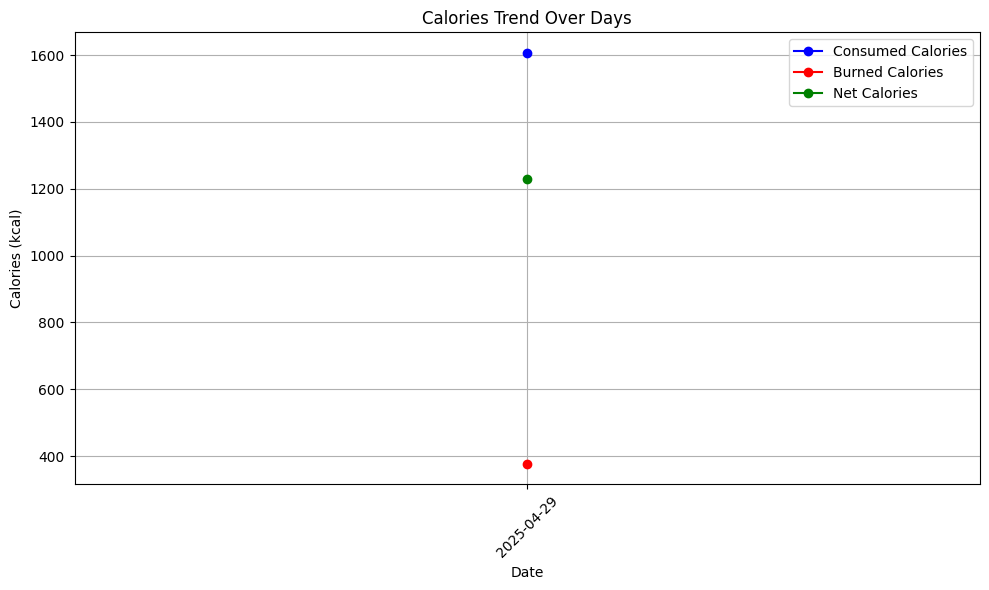

/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


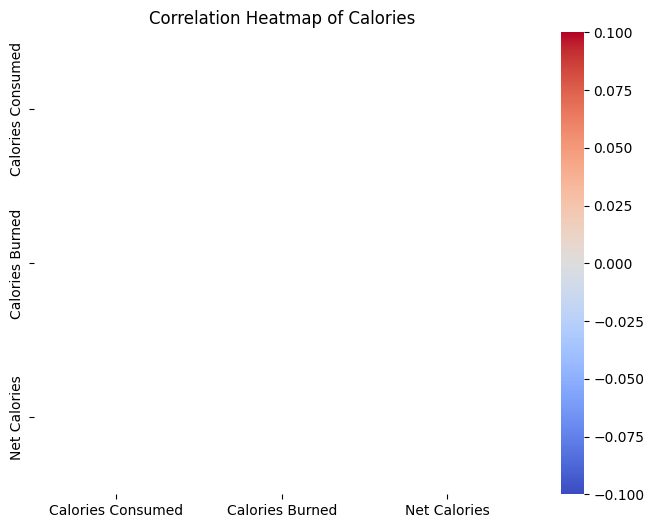

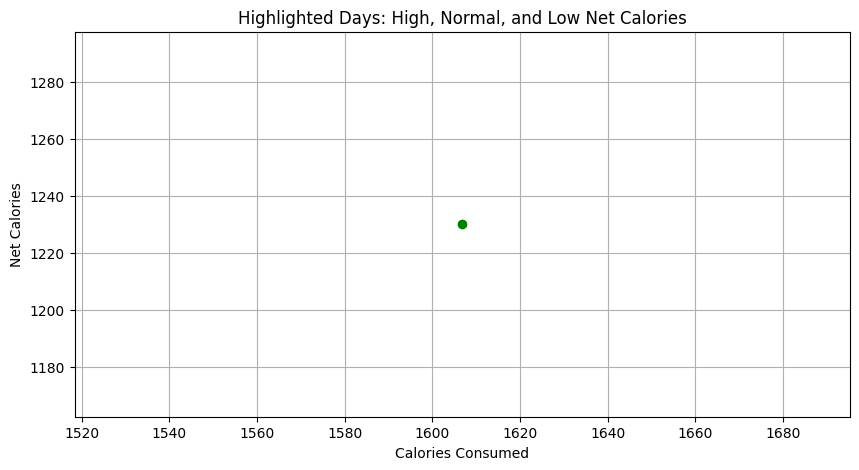

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Load and clean food data
food_df = pd.read_csv("calories (1).csv")
food_df = food_df.rename(columns={"FoodItem.1": "Food", "Cals_per100grams": "Calories_per_100g"})
food_df["Calories_per_100g"] = food_df["Calories_per_100g"].str.replace(" cal", "").astype(float)
food_df = food_df[["Food", "Calories_per_100g"]]

# Load and clean exercise data
exercise_df = pd.read_csv("exercise_dataset.csv")
exercise_df.columns = ["Exercise", "130lb", "155lb", "180lb", "205lb", "Calories_per_kg"]
exercise_df = exercise_df[["Exercise", "Calories_per_kg"]]

# Get user weight
user_weight_kg = float(input("Enter your weight in kg: "))

# Get user food input
user_foods = {}
print("\nEnter food items you ate (type 'done' when finished):")
while True:
    food = input("Food name: ").strip()
    if food.lower() == 'done':
        break
    grams = float(input(f"Enter amount of {food} in grams: "))
    user_foods[food] = grams

# Get user exercise input
user_exercises = {}
print("\nEnter exercises you did (type 'done' when finished):")
while True:
    exercise = input("Exercise name: ").strip()
    if exercise.lower() == 'done':
        break
    hours = float(input(f"Enter duration of {exercise} in hours: "))
    user_exercises[exercise] = hours

# Calculate calories consumed (track food wise)
consumed = 0
food_calories = {}
for food, grams in user_foods.items():
    food_row = food_df[food_df["Food"].str.lower() == food.lower()]
    if not food_row.empty:
        cals = food_row.iloc[0]["Calories_per_100g"] * (grams / 100)
        food_calories[food] = cals
        consumed += cals
    else:
        print(f"Warning: '{food}' not found in food database.")

# Calculate calories burned (track exercise wise)
burned = 0
exercise_calories = {}
for exercise, hours in user_exercises.items():
    ex_row = exercise_df[exercise_df["Exercise"].str.lower() == exercise.lower()]
    if not ex_row.empty:
        cal_burn = ex_row.iloc[0]["Calories_per_kg"] * user_weight_kg * hours
        exercise_calories[exercise] = cal_burn
        burned += cal_burn
    else:
        print(f"Warning: '{exercise}' not found in exercise database.")

# Net calorie calculation
net_calories = consumed - burned

# Display result
print(f"\n--- DAILY CALORIE SUMMARY ---")
print(f"Total Calories Consumed: {consumed:.2f} kcal")
print(f"Total Calories Burned: {burned:.2f} kcal")
print(f"Net Calories: {net_calories:.2f} kcal")

# --------- Linear Regression Part ---------

# Create dummy dataset for modeling
np.random.seed(42)
dummy_data = {
    "Consumed": np.random.normal(loc=consumed, scale=100, size=50),
    "Burned": np.random.normal(loc=burned, scale=50, size=50)
}
dummy_df = pd.DataFrame(dummy_data)
dummy_df["Net"] = dummy_df["Consumed"] - dummy_df["Burned"]

# Prepare data
X = dummy_df[["Consumed", "Burned"]]
y = dummy_df["Net"]

# Train the model
model = LinearRegression()
model.fit(X, y)

# Predict today's net calories
predicted_net = model.predict([[consumed, burned]])

print(f"\nPredicted Net Calories (via Linear Regression): {predicted_net[0]:.2f} kcal")

# --------- Visualization Part ---------

# Bar plot: Total Consumed vs Burned
plt.figure(figsize=(8, 6))
sns.barplot(x=['Calories Consumed', 'Calories Burned'], y=[consumed, burned], palette="Set2")
plt.title("Daily Calorie Intake vs Burn")
plt.ylabel("Calories (kcal)")
plt.show()

# Pie chart: Calories distribution
plt.figure(figsize=(6,6))
plt.pie([consumed, burned], labels=["Consumed", "Burned"], autopct='%1.1f%%', colors=["lightblue", "lightcoral"], startangle=140)
plt.title("Calories Distribution")
plt.show()

# Scatter plot: Regression line for consumed vs net
plt.figure(figsize=(8, 6))
sns.regplot(x=dummy_df["Consumed"], y=dummy_df["Net"], scatter_kws={'color':'blue'}, line_kws={'color':'red'})
plt.scatter(consumed, net_calories, color='green', label="Today's Data")
plt.xlabel("Calories Consumed")
plt.ylabel("Net Calories")
plt.title("Regression: Consumed Calories vs Net Calories")
plt.legend()
plt.show()

# Graph-Exercise vs Calories Burned
if exercise_calories:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(exercise_calories.keys()), y=list(exercise_calories.values()), palette="rocket")
    plt.title("Calories Burned per Exercise")
    plt.ylabel("Calories Burned")
    plt.xticks(rotation=45)
    plt.show()

# Graph Food vs Calories Consumed
if food_calories:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(food_calories.keys()), y=list(food_calories.values()), palette="mako")
    plt.title("Calories Consumed per Food Item")
    plt.ylabel("Calories Consumed")
    plt.xticks(rotation=45)
    plt.show()
import os
from datetime import datetime

# --------- Save Report Part ---------

# Create a dictionary for today's report
today = datetime.now().strftime("%Y-%m-%d")
report_data = {
    "Date": today,
    "Calories Consumed": consumed,
    "Calories Burned": burned,
    "Net Calories": net_calories,
    "Predicted Net Calories": predicted_net[0]
}

# Define the report file name
report_file = "calorie_report.csv"

# Check if file exists
if os.path.exists(report_file):
    # If exists, append today's data
    report_df = pd.read_csv(report_file)
    report_df = pd.concat([report_df, pd.DataFrame([report_data])], ignore_index=True)
else:
    # If not, create new file
    report_df = pd.DataFrame([report_data])

# Save to CSV
report_df.to_csv(report_file, index=False)

print(f"\n✅ Today's report saved successfully to '{report_file}'!")
# --------- Summary Dashboard Part ---------

# Load the full report
report_df = pd.read_csv(report_file)

# Basic summary statistics
total_days = len(report_df)
avg_consumed = report_df["Calories Consumed"].mean()
avg_burned = report_df["Calories Burned"].mean()
avg_net = report_df["Net Calories"].mean()

best_day = report_df.loc[report_df["Net Calories"].idxmin()]
worst_day = report_df.loc[report_df["Net Calories"].idxmax()]

print("\n📋 --- SUMMARY DASHBOARD --- 📋")
print(f"Total Days Tracked: {total_days}")
print(f"Average Calories Consumed: {avg_consumed:.2f} kcal")
print(f"Average Calories Burned: {avg_burned:.2f} kcal")
print(f"Average Net Calories: {avg_net:.2f} kcal")

print(f"\n✅ Best Day (Lowest Net Calories): {best_day['Date']} ({best_day['Net Calories']:.2f} kcal)")
print(f"⚠️ Worst Day (Highest Net Calories): {worst_day['Date']} ({worst_day['Net Calories']:.2f} kcal)")

# Plotting Calories over Time
plt.figure(figsize=(10,6))
plt.plot(report_df["Date"], report_df["Calories Consumed"], marker='o', label='Consumed Calories', color='blue')
plt.plot(report_df["Date"], report_df["Calories Burned"], marker='o', label='Burned Calories', color='red')
plt.plot(report_df["Date"], report_df["Net Calories"], marker='o', label='Net Calories', color='green')
plt.xlabel("Date")
plt.ylabel("Calories (kcal)")
plt.title("Calories Trend Over Days")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# # Correlation Heatmap
# plt.figure(figsize=(8,6))
# sns.heatmap(df[['Calories_Consumed', 'Calories_Burned', 'Net_Calories']].corr(), annot=True, cmap='coolwarm')
# plt.title('Correlation Heatmap of Calories')
# plt.show()

# # Define thresholds for high and low net calories
# high_threshold = df['Net_Calories'].mean() + df['Net_Calories'].std()
# low_threshold = df['Net_Calories'].mean() - df['Net_Calories'].std()

# # Create a new column 'Calorie_Status'
# df['Calorie_Status'] = df['Net_Calories'].apply(lambda x: 'High' if x > high_threshold else ('Low' if x < low_threshold else 'Normal'))

# # Visualizing
# plt.figure(figsize=(10,5))
# colors = df['Calorie_Status'].map({'High':'red', 'Low':'blue', 'Normal':'green'})
# plt.scatter(df['Calories_Consumed'], df['Net_Calories'], c=colors)
# plt.title('Highlighted Days: High, Normal, and Low Net Calories')
# plt.xlabel('Calories Consumed')
# plt.ylabel('Net Calories')
# plt.grid(True)
# plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(report_df[['Calories Consumed', 'Calories Burned', 'Net Calories']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Calories')
plt.show()

# Define thresholds for high and low net calories
high_threshold = report_df['Net Calories'].mean() + report_df['Net Calories'].std()
low_threshold = report_df['Net Calories'].mean() - report_df['Net Calories'].std()

# Create a new column 'Calorie_Status'
report_df['Calorie_Status'] = report_df['Net Calories'].apply(lambda x: 'High' if x > high_threshold else ('Low' if x < low_threshold else 'Normal'))

# Visualizing
plt.figure(figsize=(10,5))
colors = report_df['Calorie_Status'].map({'High':'red', 'Low':'blue', 'Normal':'green'})
plt.scatter(report_df['Calories Consumed'], report_df['Net Calories'], c=colors)
plt.title('Highlighted Days: High, Normal, and Low Net Calories')
plt.xlabel('Calories Consumed')
plt.ylabel('Net Calories')
plt.grid(True)
plt.show()

# # Also show how many days are High, Low, Normal
# print(report_df['Calorie_Status'].value_counts())
# # Also show how many days are High, Low, Normal
# print(df['Calorie_Status'].value_counts())
